<a href="https://colab.research.google.com/github/Preetham-HD/ml_Lab/blob/main/WEEK4/WEEK4_ML_id3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Classification (Iris) Accuracy: 0.7333333333333333
Decision Tree Classification (Iris) F1 Score: 0.712962962962963
Decision Tree Classification (Iris) Confusion Matrix:
 [[ 8  2  0]
 [ 0  3  6]
 [ 0  0 11]]


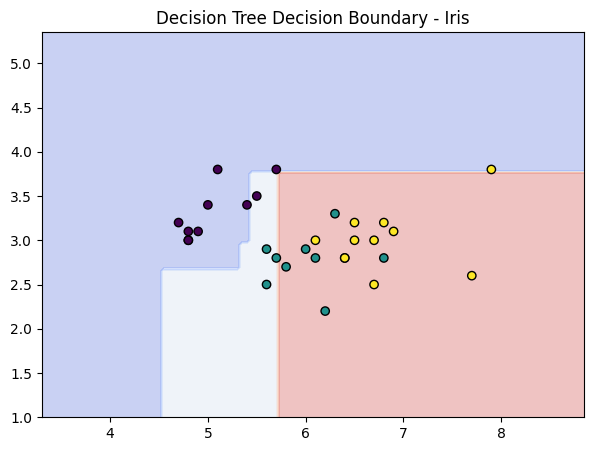

Decision Tree Classification (Digits) Accuracy: 0.5361111111111111
Decision Tree Classification (Digits) F1 Score: 0.5204063184587763
Decision Tree Classification (Digits) Confusion Matrix:
 [[24  2  0  0  1  0  5  0  1  0]
 [ 1 16  0  0  0  4  0  2  5  0]
 [ 0  3 16 11  0  0  0  0  3  0]
 [ 0  2  3 22  0  3  0  1  3  0]
 [ 4  1  0  0 41  0  0  0  0  0]
 [ 1 11  1  9  0  3  0  4 16  2]
 [ 3  0  0  0  0  0 32  0  0  0]
 [ 0  2  0  4  0  0  0 25  2  1]
 [ 0  9  0  5  0  5  0  2  9  0]
 [ 0  4  4 10  0  2  0  2 13  5]]


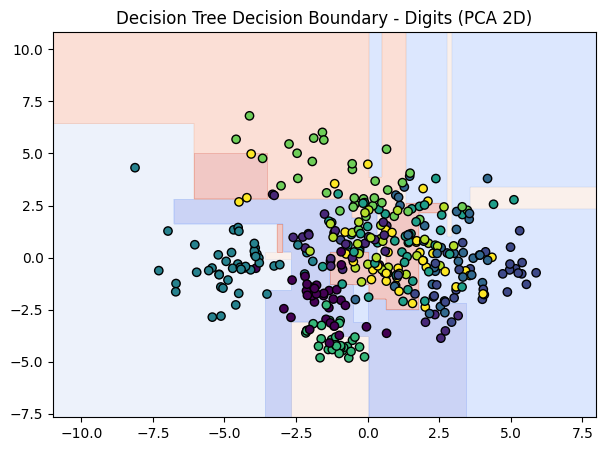

Decision Tree Regression (Diabetes) RMSE: 77.93938938203608


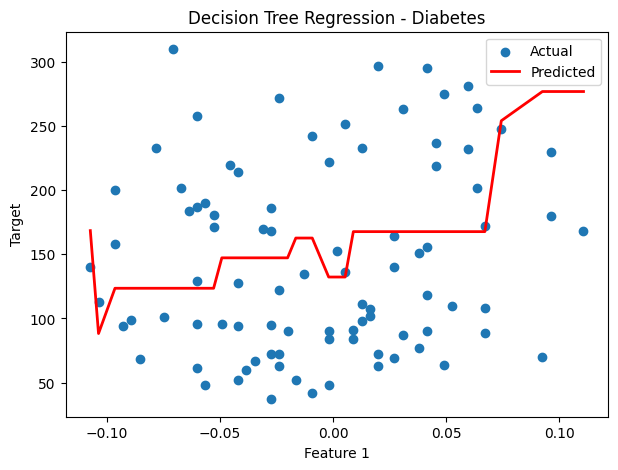

Decision Tree Regression (Auto MPG) RMSE: 4.174151730558545


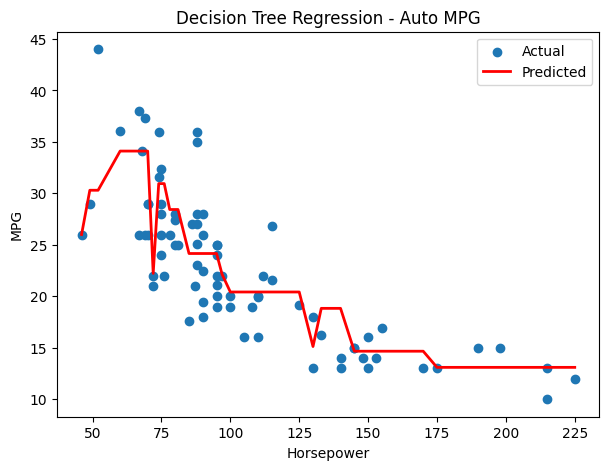

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from sklearn.datasets import load_iris, load_digits, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, confusion_matrix
import math

# ================= DECISION TREE CLASSIFIER ================= #
class DecisionTreeClassifier:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _best_split(self, X, y):
        best_gain = -1
        split_idx, split_thresh = None, None
        parent_entropy = self._entropy(y)
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for thresh in thresholds:
                left = y[X[:, feature] <= thresh]
                right = y[X[:, feature] > thresh]
                if len(left) == 0 or len(right) == 0:
                    continue
                gain = parent_entropy - (len(left)/len(y))*self._entropy(left) - (len(right)/len(y))*self._entropy(right)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feature
                    split_thresh = thresh
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(set(y)) == 1:
            return Counter(y).most_common(1)[0][0]
        feat, thresh = self._best_split(X, y)
        if feat is None:
            return Counter(y).most_common(1)[0][0]
        left_idx = X[:, feat] <= thresh
        right_idx = X[:, feat] > thresh
        left = self._build_tree(X[left_idx], y[left_idx], depth+1)
        right = self._build_tree(X[right_idx], y[right_idx], depth+1)
        return (feat, thresh, left, right)

    def _predict(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feat, thresh, left, right = tree
        if x[feat] <= thresh:
            return self._predict(x, left)
        else:
            return self._predict(x, right)

    def predict(self, X):
        return np.array([self._predict(x, self.tree) for x in X])

# ================= DECISION TREE REGRESSOR ================= #
class DecisionTreeRegressor:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _mse(self, y):
        return np.mean((y - np.mean(y))**2)

    def _best_split(self, X, y):
        best_error = float("inf")
        split_idx, split_thresh = None, None
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for thresh in thresholds:
                left = y[X[:, feature] <= thresh]
                right = y[X[:, feature] > thresh]
                if len(left) == 0 or len(right) == 0:
                    continue
                error = (len(left)*self._mse(left) + len(right)*self._mse(right)) / len(y)
                if error < best_error:
                    best_error = error
                    split_idx = feature
                    split_thresh = thresh
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth:
            return np.mean(y)
        feat, thresh = self._best_split(X, y)
        if feat is None:
            return np.mean(y)
        left_idx = X[:, feat] <= thresh
        right_idx = X[:, feat] > thresh
        left = self._build_tree(X[left_idx], y[left_idx], depth+1)
        right = self._build_tree(X[right_idx], y[right_idx], depth+1)
        return (feat, thresh, left, right)

    def _predict(self, x, tree):
        if not isinstance(tree, tuple):
            return tree
        feat, thresh, left, right = tree
        if x[feat] <= thresh:
            return self._predict(x, left)
        else:
            return self._predict(x, right)

    def predict(self, X):
        return np.array([self._predict(x, self.tree) for x in X])

# ================= CLASSIFICATION DATASET 1 (Iris) ================= #
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf1 = DecisionTreeClassifier(max_depth=4)
clf1.fit(X_train, y_train)
pred1 = clf1.predict(X_test)
accuracy1 = accuracy_score(y_test, pred1)
f1_1 = f1_score(y_test, pred1, average='weighted')
cm1 = confusion_matrix(y_test, pred1)
print("Decision Tree Classification (Iris) Accuracy:", accuracy1)
print("Decision Tree Classification (Iris) F1 Score:", f1_1)
print("Decision Tree Classification (Iris) Confusion Matrix:\n", cm1)

# Decision boundary
plt.figure(figsize=(7,5))
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf1.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='k')
plt.title("Decision Tree Decision Boundary - Iris")
plt.show()

# ================= CLASSIFICATION DATASET 2 (Digits) ================= #
digits = load_digits()
X = digits.data
y = digits.target

# PCA to reduce to 2D for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
clf2 = DecisionTreeClassifier(max_depth=6)
clf2.fit(X_train, y_train)
pred2 = clf2.predict(X_test)
accuracy2 = accuracy_score(y_test, pred2)
f1_2 = f1_score(y_test, pred2, average='weighted')
cm2 = confusion_matrix(y_test, pred2)
print("Decision Tree Classification (Digits) Accuracy:", accuracy2)
print("Decision Tree Classification (Digits) F1 Score:", f1_2)
print("Decision Tree Classification (Digits) Confusion Matrix:\n", cm2)

# Decision boundary
plt.figure(figsize=(7,5))
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf2.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='k')
plt.title("Decision Tree Decision Boundary - Digits (PCA 2D)")
plt.show()

# ================= REGRESSION DATASET 1 (Diabetes) ================= #
diabetes = load_diabetes()
X, y = diabetes.data[:, :1], diabetes.target  # use first feature for visualization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg1 = DecisionTreeRegressor(max_depth=4)
reg1.fit(X_train, y_train)
pred1_reg = reg1.predict(X_test)
rmse1 = math.sqrt(mean_squared_error(y_test, pred1_reg))
print("Decision Tree Regression (Diabetes) RMSE:", rmse1)

# Regression plot
plt.figure(figsize=(7,5))
sorted_idx = np.argsort(X_test[:,0])
plt.scatter(X_test[sorted_idx], y_test[sorted_idx], label="Actual")
plt.plot(X_test[sorted_idx], pred1_reg[sorted_idx], color='red', linewidth=2, label="Predicted")
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.title("Decision Tree Regression - Diabetes")
plt.legend()
plt.show()

# ================= REGRESSION DATASET 2 (Auto MPG) ================= #
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_csv(url)
data = data[['horsepower', 'mpg']].dropna()
X, y = data[['horsepower']].values, data['mpg'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg2 = DecisionTreeRegressor(max_depth=4)
reg2.fit(X_train, y_train)
pred2_reg = reg2.predict(X_test)
rmse2 = math.sqrt(mean_squared_error(y_test, pred2_reg))
print("Decision Tree Regression (Auto MPG) RMSE:", rmse2)

# Regression plot
plt.figure(figsize=(7,5))
sorted_idx = np.argsort(X_test[:,0])
plt.scatter(X_test[sorted_idx], y_test[sorted_idx], label="Actual")
plt.plot(X_test[sorted_idx], pred2_reg[sorted_idx], color='red', linewidth=2, label="Predicted")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Decision Tree Regression - Auto MPG")
plt.legend()
plt.show()